# DBSCAN Clustering from Scratch

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score

## 1. Mock Data Generation

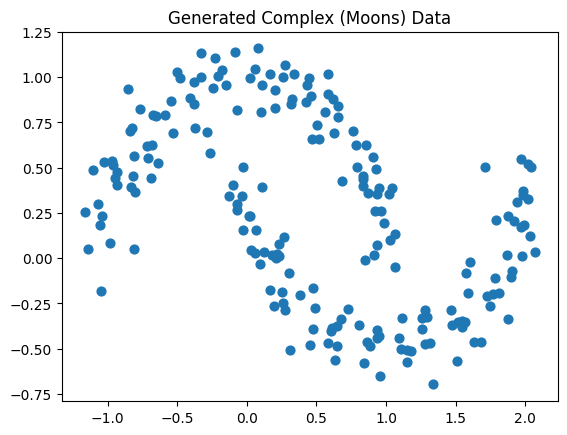

In [14]:
def get_complex_data():
    X, y = make_moons(n_samples=200, noise=0.1, random_state=0)
    return X, y

X, y_true = get_complex_data()
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Generated Complex (Moons) Data")
plt.show()

## 2. Implementation

In [15]:
class DBSCANSimple:
    def __init__(self, eps=0.2, min_pts=5):
        self.eps = eps
        self.min_pts = min_pts

    def get_neighbors(self, X, idx):
        return [i for i in range(len(X)) if np.linalg.norm(X[idx] - X[i]) < self.eps]

    def fit(self, X):
        self.labels = np.full(len(X), -1) # -1 is unvisited, 0 is noise, >0 is cluster
        curr_cluster = 0
        
        for i in range(len(X)):
            if self.labels[i] != -1: continue
            
            neighbors = self.get_neighbors(X, i)
            if len(neighbors) < self.min_pts:
                self.labels[i] = 0 # Mark as noise
            else:
                curr_cluster += 1
                self.labels[i] = curr_cluster
                
                # Expand cluster
                seed_set = neighbors[:]
                for n_idx in seed_set:
                    if self.labels[n_idx] == 0: # Noise becomes border
                        self.labels[n_idx] = curr_cluster
                    if self.labels[n_idx] != -1: continue
                    
                    self.labels[n_idx] = curr_cluster
                    new_neighbors = self.get_neighbors(X, n_idx)
                    if len(new_neighbors) >= self.min_pts:
                        seed_set.extend(new_neighbors)
        return self

## 3. Training & Measurement

In [26]:
model = DBSCANSimple(eps=0.21, min_pts=9)
model.fit(X)

# Handle noise labels for silhouette score (requires at least 2 clusters if metrics used)
if len(set(model.labels)) > 1:
    score = silhouette_score(X, model.labels)
    print(f"Finished fitting. Silhouette Score: {score:.4f}")
else:
    print("Only one cluster or noise found.")
    score = 0

Finished fitting. Silhouette Score: 0.2298


## 4. Visualization

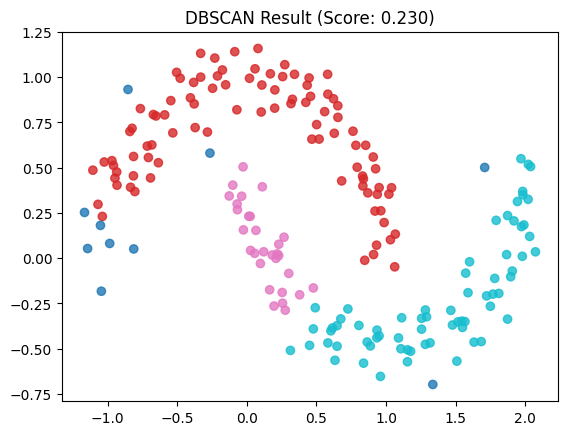

In [27]:
plt.scatter(X[:, 0], X[:, 1], c=model.labels, cmap='tab10', alpha=0.8)
plt.title(f"DBSCAN Result (Score: {score:.3f})")
plt.show()